# DenseNet201 Transfer Learning for Multi-Class Medical Image Classification

This notebook trains a DenseNet201-based classifier with the same overall philosophy as the earlier experiment:

- ImageNet-pretrained DenseNet backbone
- Medical-safe augmentation
- Class weighting for imbalance
- Two-stage training: feature extraction, then fine-tuning
- Early stopping, learning rate reduction, and checkpointing
- Full evaluation with confusion matrix, classification report, recall-focused metrics, and ROC-AUC

The default paths below are already configured for this repository:

- `data/lung_disease/train`
- `data/lung_disease/val`
- `data/lung_disease/test`

Only the dataset paths need to change for a different project.


## 1. Environment Setup

This section imports the required libraries, fixes the random seed for reproducibility, and asks TensorFlow to use the best available accelerator with this priority:

1. Dedicated GPU
2. AMD ROCm
3. DirectML-exposed iGPU on Windows
4. CPU

The notebook stays compatible with plain TensorFlow as well. If `tensorflow-directml-plugin` is installed on Windows, the code will try to use it automatically when a regular TensorFlow GPU device is not already visible.


In [1]:
!pip install -q --upgrade --force-reinstall "numpy<2.0" pandas scikit-learn matplotlib seaborn Pillow opencv-python plotly tqdm flask ipython "matplotlib-inline<0.2" "protobuf<3.20" h5py "tensorflow==2.10.*" "keras==2.10.*"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.9 MB/s eta 0:00:00
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement tensorflow==2.10.* (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.10.*


In [2]:
import os
import platform
import random
import warnings
from importlib import metadata as importlib_metadata
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
)
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import AUC
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

LOCAL_ARTIFACTS_DIR = Path("artifacts").resolve()
LOCAL_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_KERAS_CACHE = LOCAL_ARTIFACTS_DIR / "keras_cache"
LOCAL_KERAS_CACHE.mkdir(parents=True, exist_ok=True)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")

try:
    from keras.utils import data_utils as keras_data_utils

    _original_get_file = keras_data_utils.get_file

    def workspace_get_file(*args, **kwargs):
        kwargs.setdefault("cache_dir", str(LOCAL_KERAS_CACHE))
        return _original_get_file(*args, **kwargs)

    keras_data_utils.get_file = workspace_get_file
    tf.keras.utils.get_file = workspace_get_file
except Exception as exc:
    print(f"Could not patch the local Keras cache directory: {exc}")


def render_figure(fig):
    display(fig)
    plt.close(fig)


def configure_best_available_accelerator():
    directml_loaded = False
    directml_note = None

    def score_device(device_name, rocm_build):
        name = device_name.lower()

        if any(token in name for token in ["directml", "dml"]):
            return 260, "GPU via DirectML"

        if any(token in name for token in ["nvidia", "geforce", "rtx", "gtx", "quadro", "tesla", "titan", "arc"]):
            return 400, "Dedicated GPU"

        if rocm_build and any(token in name for token in ["amd", "radeon", "gfx"]):
            return 350, "AMD ROCm"

        if any(token in name for token in ["radeon rx", "radeon pro", "firepro"]):
            return 330, "Dedicated GPU"

        if any(token in name for token in ["intel", "iris", "uhd", "vega", "radeon graphics", "integrated"]):
            tier = "iGPU via DirectML" if directml_loaded else "Integrated GPU"
            return 220 if directml_loaded else 120, tier

        if "gpu" in name:
            return 250 if directml_loaded else 180, "GPU"

        return 0, "CPU"

    if platform.system() == "Windows":
        try:
            importlib_metadata.version("tensorflow-directml-plugin")
            directml_loaded = True
            directml_note = "DirectML plugin package detected."
        except importlib_metadata.PackageNotFoundError:
            directml_note = "DirectML plugin not installed; falling back to the default TensorFlow device search."
        except Exception as exc:
            directml_note = f"DirectML detection warning: {exc}"

    rocm_build = bool(tf.sysconfig.get_build_info().get("is_rocm_build", False))
    gpu_devices = tf.config.list_physical_devices("GPU")

    if not gpu_devices:
        accelerator_info = {
            "backend": "CPU",
            "device_name": "CPU",
            "directml_loaded": directml_loaded,
            "rocm_build": rocm_build,
        }
        print(f"TensorFlow version: {tf.__version__}")
        print("Selected accelerator: CPU")
        if directml_note:
            print(directml_note)
        return accelerator_info

    ranked_devices = []
    for gpu_device in gpu_devices:
        try:
            details = tf.config.experimental.get_device_details(gpu_device)
        except Exception:
            details = {}

        device_name = (
            details.get("device_name")
            or details.get("name")
            or getattr(gpu_device, "name", str(gpu_device))
        )
        lowered_name = str(device_name).lower()
        if any(token in lowered_name for token in ["directml", "dml"]):
            directml_loaded = True
            if directml_note is None:
                directml_note = "DirectML-backed TensorFlow GPU device detected."
        score, tier = score_device(str(device_name), rocm_build)
        ranked_devices.append(
            {
                "device": gpu_device,
                "device_name": str(device_name),
                "score": score,
                "tier": tier,
            }
        )

    ranked_devices.sort(key=lambda item: item["score"], reverse=True)
    selected = ranked_devices[0]

    try:
        tf.config.set_visible_devices(selected["device"], "GPU")
    except RuntimeError:
        pass

    for visible_gpu in tf.config.list_physical_devices("GPU"):
        try:
            tf.config.experimental.set_memory_growth(visible_gpu, True)
        except Exception:
            pass

    accelerator_info = {
        "backend": selected["tier"],
        "device_name": selected["device_name"],
        "directml_loaded": directml_loaded,
        "rocm_build": rocm_build,
    }
    print(f"TensorFlow version: {tf.__version__}")
    print(f"Selected accelerator: {selected['tier']} -> {selected['device_name']}")
    if directml_note:
        print(directml_note)
    return accelerator_info


ACCELERATOR_INFO = configure_best_available_accelerator()
ACCELERATOR_INFO


2026-03-08 05:10:07.395668: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772946607.581007      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772946607.631823      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772946608.069286      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772946608.069338      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772946608.069341      24 computation_placer.cc:177] computation placer alr

Could not patch the local Keras cache directory: cannot import name 'data_utils' from 'keras.utils' (/usr/local/lib/python3.12/dist-packages/keras/utils/__init__.py)
TensorFlow version: 2.19.0
Selected accelerator: Dedicated GPU -> Tesla P100-PCIE-16GB


{'backend': 'Dedicated GPU',
 'device_name': 'Tesla P100-PCIE-16GB',
 'directml_loaded': False,
 'rocm_build': False}

## 2. Dataset Configuration

Update the three path variables below if you want to train on another dataset. The notebook will automatically detect the classes from the training directory and verify that the same class mapping is used by the validation and test splits.

The local repository uses `val/`, but this notebook also supports `validation/` if you point `val_dir` there instead.


Train directory: /kaggle/input/datasets/kishore4843237/lung-disease-dataset-with-7-classes/lung_disease/train
Validation directory: /kaggle/input/datasets/kishore4843237/lung-disease-dataset-with-7-classes/lung_disease/val
Test directory: /kaggle/input/datasets/kishore4843237/lung-disease-dataset-with-7-classes/lung_disease/test


,split,class_name,image_count
0,train,atelectasis,10074
1,train,bacterial_pneumonia,10074
2,train,covid19,10074
3,train,emphysema,10074
4,train,normal,10074
5,train,tuberculosis,10074
6,train,viral_pneumonia,10074
7,validation,atelectasis,206
8,validation,bacterial_pneumonia,462
9,validation,covid19,358


Detected 7 classes: ['atelectasis', 'bacterial_pneumonia', 'covid19', 'emphysema', 'normal', 'tuberculosis', 'viral_pneumonia']


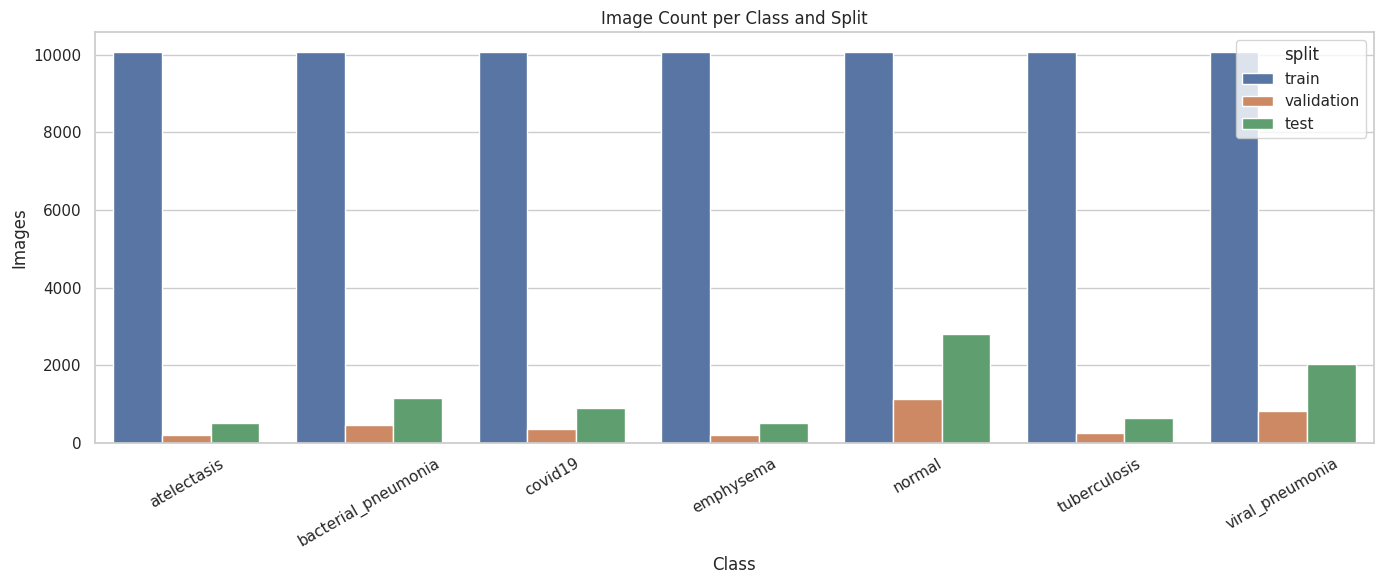

In [3]:
DATASET_ROOT = Path("/kaggle/input/datasets/kishore4843237/lung-disease-dataset-with-7-classes/lung_disease")

train_dir = DATASET_ROOT / "train"
val_dir = DATASET_ROOT / "val"
test_dir = DATASET_ROOT / "test"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
PHASE1_EPOCHS = 25
PHASE2_EPOCHS = 12
FINE_TUNE_LAYERS = 50


def resolve_split_path(path_like, alternate_paths=None):
    path = Path(path_like)
    if path.exists():
        return path

    if alternate_paths:
        for alternate in alternate_paths:
            alternate = Path(alternate)
            if alternate.exists():
                print(f"Using {alternate} because {path} was not found.")
                return alternate

    raise FileNotFoundError(f"Dataset directory not found: {path}")


train_dir = resolve_split_path(train_dir)
val_dir = resolve_split_path(val_dir, alternate_paths=[DATASET_ROOT / "validation"])
test_dir = resolve_split_path(test_dir)

print("Train directory:", train_dir.resolve())
print("Validation directory:", val_dir.resolve())
print("Test directory:", test_dir.resolve())


def index_split(split_dir, split_name):
    rows = []
    for class_dir in sorted(path for path in Path(split_dir).iterdir() if path.is_dir()):
        for file_path in class_dir.rglob("*"):
            if file_path.is_file():
                rows.append(
                    {
                        "split": split_name,
                        "class_name": class_dir.name,
                        "filepath": str(file_path),
                    }
                )

    frame = pd.DataFrame(rows)
    summary = (
        frame.groupby(["split", "class_name"], as_index=False)
        .size()
        .rename(columns={"size": "image_count"})
    )
    return frame, summary


train_files, train_summary = index_split(train_dir, "train")
val_files, val_summary = index_split(val_dir, "validation")
test_files, test_summary = index_split(test_dir, "test")

dataset_summary = pd.concat(
    [
        train_summary,
        val_summary,
        test_summary,
    ],
    ignore_index=True,
)
display(dataset_summary)

detected_classes = dataset_summary.loc[dataset_summary["split"] == "train", "class_name"].tolist()
num_classes = len(detected_classes)
print(f"Detected {num_classes} classes: {detected_classes}")

fig, ax = plt.subplots(figsize=(14, 6))
ax = sns.barplot(data=dataset_summary, x="class_name", y="image_count", hue="split")
ax.set_title("Image Count per Class and Split")
ax.set_xlabel("Class")
ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
render_figure(fig)


## 3. Data Preprocessing and Augmentation

DenseNet preprocessing is applied to all images. The training generator also adds light augmentation chosen to be reasonable for chest imaging:

- rotation up to 10 degrees
- small translations
- slight zoom and shear
- horizontal flips

Validation and test sets only receive preprocessing so they stay as clean evaluation benchmarks.


In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest",
)

eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

generator_kwargs = {
    "target_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "class_mode": "categorical",
    "color_mode": "rgb",
}

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_files,
    x_col="filepath",
    y_col="class_name",
    classes=detected_classes,
    shuffle=True,
    seed=SEED,
    validate_filenames=False,
    **generator_kwargs,
)

val_generator = eval_datagen.flow_from_dataframe(
    dataframe=val_files,
    x_col="filepath",
    y_col="class_name",
    classes=detected_classes,
    shuffle=False,
    seed=SEED,
    validate_filenames=False,
    **generator_kwargs,
)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_files,
    x_col="filepath",
    y_col="class_name",
    classes=detected_classes,
    shuffle=False,
    seed=SEED,
    validate_filenames=False,
    **generator_kwargs,
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Class indices:", train_generator.class_indices)
print("Number of classes:", num_classes)
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)


Found 70518 non-validated image filenames belonging to 7 classes.
Found 3415 non-validated image filenames belonging to 7 classes.
Found 8537 non-validated image filenames belonging to 7 classes.
Class indices: {'atelectasis': 0, 'bacterial_pneumonia': 1, 'covid19': 2, 'emphysema': 3, 'normal': 4, 'tuberculosis': 5, 'viral_pneumonia': 6}
Number of classes: 7
Training samples: 70518
Validation samples: 3415
Test samples: 8537


## 4. Class Weight Calculation

Class weights are computed from the training labels so the optimizer pays more attention to under-represented classes when the dataset is imbalanced.


In [5]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes,
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(np.unique(train_generator.classes), class_weight_values)
}

class_weight_frame = pd.DataFrame(
    {
        "class_name": class_names,
        "class_id": list(range(num_classes)),
        "class_weight": [class_weights[class_id] for class_id in range(num_classes)],
    }
)
display(class_weight_frame)


,class_name,class_id,class_weight
0,atelectasis,0,1.0
1,bacterial_pneumonia,1,1.0
2,covid19,2,1.0
3,emphysema,3,1.0
4,normal,4,1.0
5,tuberculosis,5,1.0
6,viral_pneumonia,6,1.0


## 5. Model Architecture

The model uses an ImageNet-pretrained DenseNet201 backbone followed by a compact fully connected head:

- `GlobalAveragePooling2D`
- `Dense(1024, activation="swish")`
- `BatchNormalization`
- `Dropout(0.3)`
- `Dense(512, activation="swish")`
- `BatchNormalization`
- `Dropout(0.25)`
- `Dense(256, activation="swish")`
- `Dense(num_classes, activation="softmax")`

The model is created with the Functional API so it remains easy to extend later.


In [6]:
def build_densenet201_classifier(num_classes, input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape, name="input_image")
    base_model = DenseNet201(
        weights="imagenet",
        include_top=False,
        input_tensor=inputs,
    )
    base_model.trainable = False

    x = base_model.outputs[0]
    x = GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = Dense(1024, activation="swish", name="dense_1024")(x)
    x = BatchNormalization(name="batch_norm_1024")(x)
    x = Dropout(0.3, name="dropout_1024")(x)
    x = Dense(512, activation="swish", name="dense_512")(x)
    x = BatchNormalization(name="batch_norm_512")(x)
    x = Dropout(0.25, name="dropout_512")(x)
    x = Dense(256, activation="swish", name="dense_256")(x)
    outputs = Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs, name="densenet201_transfer_classifier")
    return model, base_model


model, base_model = build_densenet201_classifier(
    num_classes=num_classes,
    input_shape=IMAGE_SIZE + (3,),
)

model.summary(line_length=120)


I0000 00:00:1772946792.727417      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "densenet201_transfer_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ input_image (InputLayer)          │ (None, 224, 224, 3)          │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ zero_padding2d (ZeroPadding2D)    │ (None, 230, 230, 3)          │                 0 │ input_image[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_conv (Conv2D)               │ (None, 112, 112, 64)         │             9,408 │ zero_padding2d[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_bn (BatchNormalization)     │ (None, 112, 112, 64)         │               256 │ conv1_conv[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv1_relu (Activation)           │ (None, 112, 112, 64)         │                 0 │ conv1_bn[0][0]            
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ zero_padding2d_1 (ZeroPadding2D)  │ (None, 114, 114, 64)         │                 0 │ conv1_relu[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ pool1 (MaxPooling2D)              │ (None, 56, 56, 64)           │                 0 │ zero_padding2d_1[0][0]    
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_0_bn                 │ (None, 56, 56, 64)           │               256 │ pool1[0][0]               
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_0_relu (Activation)  │ (None, 56, 56, 64)           │                 0 │ conv2_block1_0_bn[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_conv (Conv2D)      │ (None, 56, 56, 128)          │             8,192 │ conv2_block1_0_relu[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_bn                 │ (None, 56, 56, 128)          │               512 │ conv2_block1_1_conv[0][0] 
│ (BatchNormalization)              │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_1_relu (Activation)  │ (None, 56, 56, 128)          │                 0 │ conv2_block1_1_bn[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_2_conv (Conv2D)      │ (None, 56, 56, 32)           │            36,864 │ conv2_block1_1_relu[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block1_concat (Concatenate) │ (None, 56, 56, 96)           │                 0 │ pool1[0][0],              
│                                   │                              │                   │ conv2_block1_2_conv[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ conv2_block2_0_bn                 │ (None, 56, 56, 96)

 Total params: 20,953,159 (79.93 MB)

 Trainable params: 2,628,103 (10.03 MB)

 Non-trainable params: 18,325,056 (69.90 MB)

## 6. Phase 1 Training: Feature Extraction

The DenseNet backbone stays frozen in this stage. Only the custom classification head is trained.

- Optimizer: `Adam(1e-4)`
- Loss: `CategoricalCrossentropy(label_smoothing=0.1)`
- Metrics: `accuracy` and multi-class ROC-AUC
- Callbacks: early stopping, LR reduction, best-checkpoint saving


In [7]:
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

phase1_checkpoint_path = CHECKPOINT_DIR / "densenet201_phase1_best.h5"
phase2_checkpoint_path = CHECKPOINT_DIR / "densenet201_phase2_best.h5"


def compile_model(model, learning_rate, num_classes):
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=[
            "accuracy",
            AUC(name="auc", multi_label=True, num_labels=num_classes, curve="ROC"),
        ],
    )


def build_callbacks(checkpoint_path):
    return [
        EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
    ]


compile_model(model, learning_rate=1e-4, num_classes=num_classes)

phase1_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weights,
    callbacks=build_callbacks(phase1_checkpoint_path),
    verbose=1,
)


Epoch 1/25


I0000 00:00:1772946826.187924      77 service.cc:152] XLA service 0x7deb5c0026c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772946826.187966      77 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772946832.037888      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/2204 ━━━━━━━━━━━━━━━━━━━━ 3:10 86ms/step - accuracy: 0.1250 - auc: 0.4428 - loss: 2.5966   

I0000 00:00:1772946856.053120      77 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.6969 - auc: 0.9370 - loss: 1.0941
Epoch 1: val_auc improved from -inf to 0.97396, saving model to /kaggle/working/checkpoints/densenet201_phase1_best.h5


...

2204/2204 ━━━━━━━━━━━━━━━━━━━━ 946s 429ms/step - accuracy: 0.8661 - auc: 0.9851 - loss: 0.7162 - val_accuracy: 0.8217 - val_auc: 0.9791 - val_loss: 0.7530 - learning_rate: 1.0000e-04
Epoch 6/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8746 - auc: 0.9864 - loss: 0.6993
Epoch 6: val_auc did not improve from 0.97908
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 941s 427ms/step - accuracy: 0.8746 - auc: 0.9864 - loss: 0.6993 - val_accuracy: 0.8316 - val_auc: 0.9786 - val_loss: 0.7635 - learning_rate: 1.0000e-04
Epoch 7/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8770 - auc: 0.9870 - loss: 0.6896
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.

Epoch 7: val_auc did not improve from 0.97908
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 953s 433ms/step - accuracy: 0.8770 - auc: 0.9870 - loss: 0.6896 - val_accuracy: 0.8384 - val_auc: 0.9780 - val_loss: 0.7644 - learning_rate: 1.0000e-04
Epoch 8/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.888

2204/2204 ━━━━━━━━━━━━━━━━━━━━ 929s 421ms/step - accuracy: 0.8889 - auc: 0.9889 - loss: 0.6678 - val_accuracy: 0.8372 - val_auc: 0.9800 - val_loss: 0.7349 - learning_rate: 3.0000e-05
Epoch 9/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8956 - auc: 0.9896 - loss: 0.6564
Epoch 9: val_auc improved from 0.98000 to 0.98053, saving model to /kaggle/working/checkpoints/densenet201_phase1_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 935s 424ms/step - accuracy: 0.8956 - auc: 0.9896 - loss: 0.6564 - val_accuracy: 0.8389 - val_auc: 0.9805 - val_loss: 0.7279 - learning_rate: 3.0000e-05
Epoch 10/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8945 - auc: 0.9898 - loss: 0.6555
Epoch 10: val_auc improved from 0.98053 to 0.98103, saving model to /kaggle/working/checkpoints/densenet201_phase1_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 934s 424ms/step - accuracy: 0.8945 - auc: 0.9898 - loss: 0.6555 - val_accuracy: 0.8407 - val_auc: 0.9810 - val_loss: 0.7170 - learning_rate: 3.0000e-05
Epoch 11/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.8965 - auc: 0.9900 - loss: 0.6537
Epoch 11: val_auc did not improve from 0.98103
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 939s 426ms/step - accuracy: 0.8965 - auc: 0.9900 - loss: 0.6537 - val_accuracy: 0.8384 - val_auc: 0.9807 - val_loss: 0.7215 - learning_rate: 3.0000e-05
Epoch 12/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9010 - auc: 0.9907 - loss: 0.6443
Epoch 12: val_auc improved from 0.98103 to 0.98145, saving model to /kaggle/working/checkpoints/densenet201_phase1_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 924s 419ms/step - accuracy: 0.9010 - auc: 0.9907 - loss: 0.6443 - val_accuracy: 0.8495 - val_auc: 0.9815 - val_loss: 0.7133 - learning_rate: 3.0000e-05
Epoch 13/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8999 - auc: 0.9906 - loss: 0.6445
Epoch 13: val_auc did not improve from 0.98145
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 937s 425ms/step - accuracy: 0.8999 - auc: 0.9906 - loss: 0.6445 - val_accuracy: 0.8416 - val_auc: 0.9807 - val_loss: 0.7160 - learning_rate: 3.0000e-05
Epoch 14/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9035 - auc: 0.9906 - loss: 0.6431
Epoch 14: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.

Epoch 14: val_auc did not improve from 0.98145
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 942s 427ms/step - accuracy: 0.9035 - auc: 0.9906 - loss: 0.6431 - val_accuracy: 0.8428 - val_auc: 0.9802 - val_loss: 0.7207 - learning_rate: 3.0000e-05
Epoch 15/25
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 

## 7. Phase 2 Training: Fine-Tuning

After the classification head stabilizes, the last 50 DenseNet layers are unfrozen and the entire model is recompiled with a smaller learning rate for careful fine-tuning.


In [8]:
def unfreeze_last_layers(base_model, n_layers=50):
    base_model.trainable = True
    n_layers = min(n_layers, len(base_model.layers))

    for layer in base_model.layers[:-n_layers]:
        layer.trainable = False

    for layer in base_model.layers[-n_layers:]:
        layer.trainable = True

    return n_layers


unfrozen_layers = unfreeze_last_layers(base_model, n_layers=FINE_TUNE_LAYERS)
print(f"Unfroze the last {unfrozen_layers} layers of DenseNet201 for fine-tuning.")

compile_model(model, learning_rate=1e-5, num_classes=num_classes)

phase2_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=PHASE2_EPOCHS,
    class_weight=class_weights,
    callbacks=build_callbacks(phase2_checkpoint_path),
    verbose=1,
)

model = tf.keras.models.load_model(phase2_checkpoint_path)
print(f"Loaded best fine-tuned checkpoint from {phase2_checkpoint_path.resolve()}")


Unfroze the last 50 layers of DenseNet201 for fine-tuning.
Epoch 1/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8747 - auc: 0.9869 - loss: 0.6942
Epoch 1: val_auc improved from -inf to 0.98023, saving model to /kaggle/working/checkpoints/densenet201_phase2_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 1102s 473ms/step - accuracy: 0.8747 - auc: 0.9869 - loss: 0.6941 - val_accuracy: 0.8489 - val_auc: 0.9802 - val_loss: 0.7267 - learning_rate: 1.0000e-05
Epoch 2/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.8919 - auc: 0.9896 - loss: 0.6584
Epoch 2: val_auc improved from 0.98023 to 0.98112, saving model to /kaggle/working/checkpoints/densenet201_phase2_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 952s 432ms/step - accuracy: 0.8919 - auc: 0.9896 - loss: 0.6584 - val_accuracy: 0.8483 - val_auc: 0.9811 - val_loss: 0.7151 - learning_rate: 1.0000e-05
Epoch 3/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9000 - auc: 0.9903 - loss: 0.6462
Epoch 3: val_auc did not improve from 0.98112
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 959s 435ms/step - accuracy: 0.9000 - auc: 0.9903 - loss: 0.6462 - val_accuracy: 0.8486 - val_auc: 0.9809 - val_loss: 0.7166 - learning_rate: 1.0000e-05
Epoch 4/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9026 - auc: 0.9910 - loss: 0.6360
Epoch 4: val_auc improved from 0.98112 to 0.98176, saving model to /kaggle/working/checkpoints/densenet201_phase2_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 958s 435ms/step - accuracy: 0.9026 - auc: 0.9910 - loss: 0.6360 - val_accuracy: 0.8521 - val_auc: 0.9818 - val_loss: 0.7078 - learning_rate: 1.0000e-05
Epoch 5/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9075 - auc: 0.9914 - loss: 0.6299
Epoch 5: val_auc improved from 0.98176 to 0.98288, saving model to /kaggle/working/checkpoints/densenet201_phase2_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 999s 453ms/step - accuracy: 0.9075 - auc: 0.9914 - loss: 0.6299 - val_accuracy: 0.8571 - val_auc: 0.9829 - val_loss: 0.6932 - learning_rate: 1.0000e-05
Epoch 6/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9100 - auc: 0.9917 - loss: 0.6241
Epoch 6: val_auc did not improve from 0.98288
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 963s 437ms/step - accuracy: 0.9100 - auc: 0.9917 - loss: 0.6241 - val_accuracy: 0.8551 - val_auc: 0.9821 - val_loss: 0.7017 - learning_rate: 1.0000e-05
Epoch 7/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9140 - auc: 0.9922 - loss: 0.6180
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 7: val_auc did not improve from 0.98288
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 1076s 488ms/step - accuracy: 0.9140 - auc: 0.9922 - loss: 0.6180 - val_accuracy: 0.8565 - val_auc: 0.9825 - val_loss: 0.7017 - learning_rate: 1.0000e-05
Epoch 8/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.91

2204/2204 ━━━━━━━━━━━━━━━━━━━━ 974s 442ms/step - accuracy: 0.9182 - auc: 0.9927 - loss: 0.6111 - val_accuracy: 0.8592 - val_auc: 0.9830 - val_loss: 0.6941 - learning_rate: 3.0000e-06
Epoch 10/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9192 - auc: 0.9929 - loss: 0.6092
Epoch 10: val_auc did not improve from 0.98304
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 952s 432ms/step - accuracy: 0.9192 - auc: 0.9929 - loss: 0.6092 - val_accuracy: 0.8586 - val_auc: 0.9830 - val_loss: 0.6945 - learning_rate: 9.0000e-07
Epoch 11/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9187 - auc: 0.9928 - loss: 0.6104
Epoch 11: val_auc improved from 0.98304 to 0.98317, saving model to /kaggle/working/checkpoints/densenet201_phase2_best.h5


2204/2204 ━━━━━━━━━━━━━━━━━━━━ 959s 435ms/step - accuracy: 0.9187 - auc: 0.9928 - loss: 0.6104 - val_accuracy: 0.8594 - val_auc: 0.9832 - val_loss: 0.6912 - learning_rate: 9.0000e-07
Epoch 12/12
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9201 - auc: 0.9931 - loss: 0.6073
Epoch 12: val_auc did not improve from 0.98317
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 959s 435ms/step - accuracy: 0.9201 - auc: 0.9931 - loss: 0.6073 - val_accuracy: 0.8589 - val_auc: 0.9830 - val_loss: 0.6923 - learning_rate: 9.0000e-07
Restoring model weights from the end of the best epoch: 11.


Loaded best fine-tuned checkpoint from /kaggle/working/checkpoints/densenet201_phase2_best.h5


## 8. Training Visualization

The plots below merge both training stages and mark the transition from frozen-backbone training to fine-tuning.


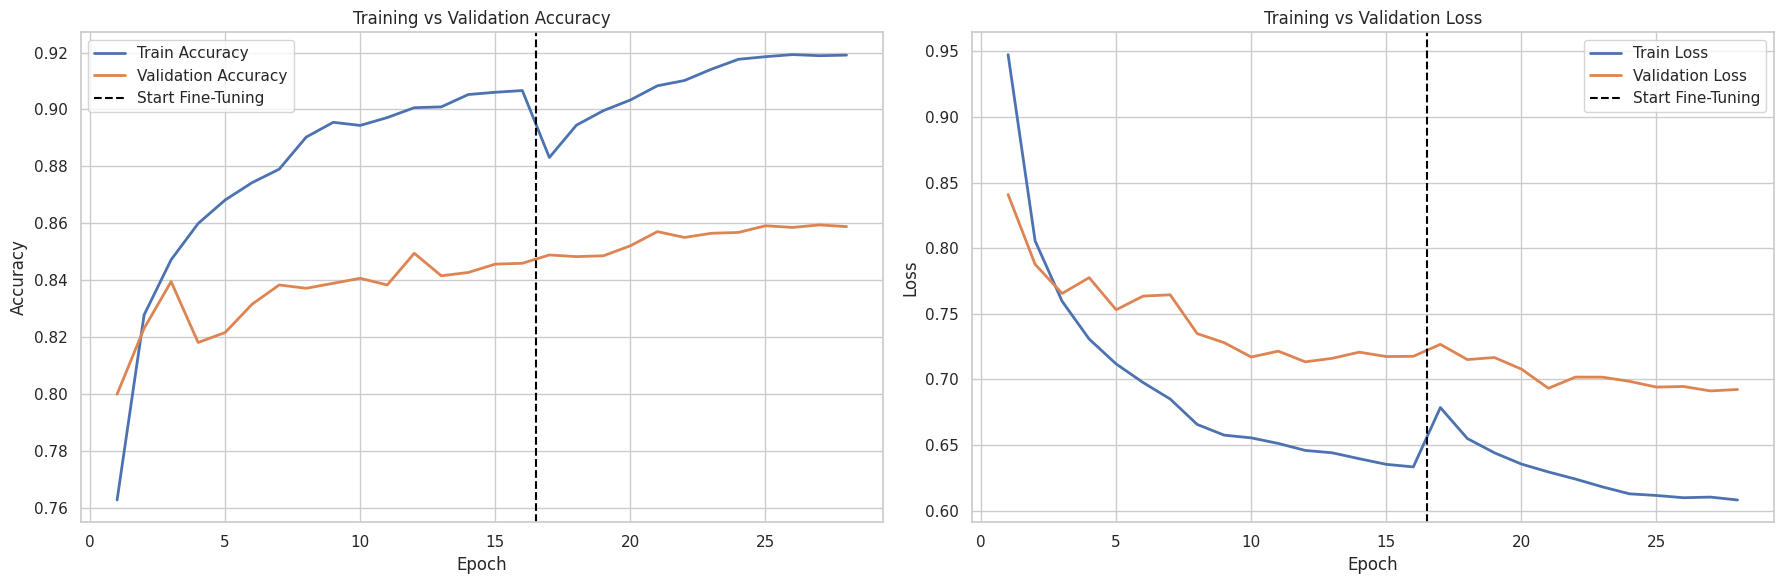

,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate
epoch,,,,,,,
24,0.917624,0.992558,0.612726,0.856808,0.982653,0.698476,3.000000e-06
25,0.918531,0.992771,0.611461,0.859151,0.983037,0.694086,3.000000e-06
26,0.919269,0.992804,0.609754,0.858565,0.982992,0.694548,9.000000e-07
27,0.918886,0.992738,0.610226,0.859444,0.983165,0.691164,9.000000e-07
28,0.919084,0.992946,0.608028,0.858858,0.983048,0.692282,9.000000e-07


In [9]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        for metric_name, values in history.history.items():
            merged.setdefault(metric_name, []).extend(values)
    return merged


full_history = merge_histories(phase1_history, phase2_history)
epoch_index = np.arange(1, len(full_history["loss"]) + 1)
fine_tune_start_epoch = len(phase1_history.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(epoch_index, full_history["accuracy"], label="Train Accuracy", linewidth=2)
axes[0].plot(epoch_index, full_history["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[0].axvline(fine_tune_start_epoch + 0.5, color="black", linestyle="--", label="Start Fine-Tuning")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epoch_index, full_history["loss"], label="Train Loss", linewidth=2)
axes[1].plot(epoch_index, full_history["val_loss"], label="Validation Loss", linewidth=2)
axes[1].axvline(fine_tune_start_epoch + 0.5, color="black", linestyle="--", label="Start Fine-Tuning")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

fig.tight_layout()
render_figure(fig)

history_frame = pd.DataFrame(full_history)
history_frame.index = np.arange(1, len(history_frame) + 1)
history_frame.index.name = "epoch"
display(history_frame.tail())


## 9. Model Evaluation

Evaluation is performed on the validation and test splits. The test analysis includes:

- confusion matrix
- classification report
- weighted precision, recall, and F1-score
- multi-class ROC-AUC with one-vs-rest averaging
- per-class ROC curves and AUC values


In [10]:
evaluation_rows = []

for split_name, generator in [("validation", val_generator), ("test", test_generator)]:
    metrics = model.evaluate(generator, verbose=1, return_dict=True)
    metrics["split"] = split_name
    evaluation_rows.append(metrics)

evaluation_frame = pd.DataFrame(evaluation_rows).set_index("split")
display(evaluation_frame.style.format("{:.4f}"))


107/107 ━━━━━━━━━━━━━━━━━━━━ 60s 295ms/step - accuracy: 0.8316 - auc: 0.6571 - loss: 0.7003
267/267 ━━━━━━━━━━━━━━━━━━━━ 118s 443ms/step - accuracy: 0.8265 - auc: 0.6511 - loss: 0.7137


,accuracy,auc,loss
split,,,
validation,0.8594,0.9832,0.6912
test,0.8559,0.9829,0.7019


In [11]:
test_generator.reset()
predicted_probabilities = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predicted_probabilities, axis=1)
true_classes = test_generator.classes

true_one_hot = label_binarize(true_classes, classes=np.arange(num_classes))

summary_metrics = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(true_classes, predicted_classes),
            "precision_weighted": precision_score(
                true_classes,
                predicted_classes,
                average="weighted",
                zero_division=0,
            ),
            "recall_weighted": recall_score(
                true_classes,
                predicted_classes,
                average="weighted",
                zero_division=0,
            ),
            "f1_weighted": f1_score(
                true_classes,
                predicted_classes,
                average="weighted",
                zero_division=0,
            ),
            "roc_auc_macro_ovr": roc_auc_score(
                true_one_hot,
                predicted_probabilities,
                multi_class="ovr",
                average="macro",
            ),
            "roc_auc_weighted_ovr": roc_auc_score(
                true_one_hot,
                predicted_probabilities,
                multi_class="ovr",
                average="weighted",
            ),
        }
    ],
    index=["test"],
)
display(summary_metrics.style.format("{:.4f}"))

classification_report_frame = pd.DataFrame(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
).transpose()
display(classification_report_frame.style.format("{:.4f}"))


267/267 ━━━━━━━━━━━━━━━━━━━━ 75s 199ms/step


,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,roc_auc_weighted_ovr
test,0.8559,0.8505,0.8559,0.8511,0.9829,0.9784


,precision,recall,f1-score,support
atelectasis,0.9809,1.0000,0.9904,514.0000
bacterial_pneumonia,0.6617,0.5026,0.5713,1156.0000
covid19,0.9084,0.8982,0.9033,894.0000
emphysema,0.9451,0.9118,0.9281,510.0000
normal,0.9144,0.9804,0.9462,2799.0000
tuberculosis,0.9934,0.9437,0.9679,639.0000
viral_pneumonia,0.7424,0.7886,0.7648,2025.0000
accuracy,0.8559,0.8559,0.8559,0.8559
macro avg,0.8781,0.8607,0.8674,8537.0000
weighted avg,0.8505,0.8559,0.8511,8537.0000


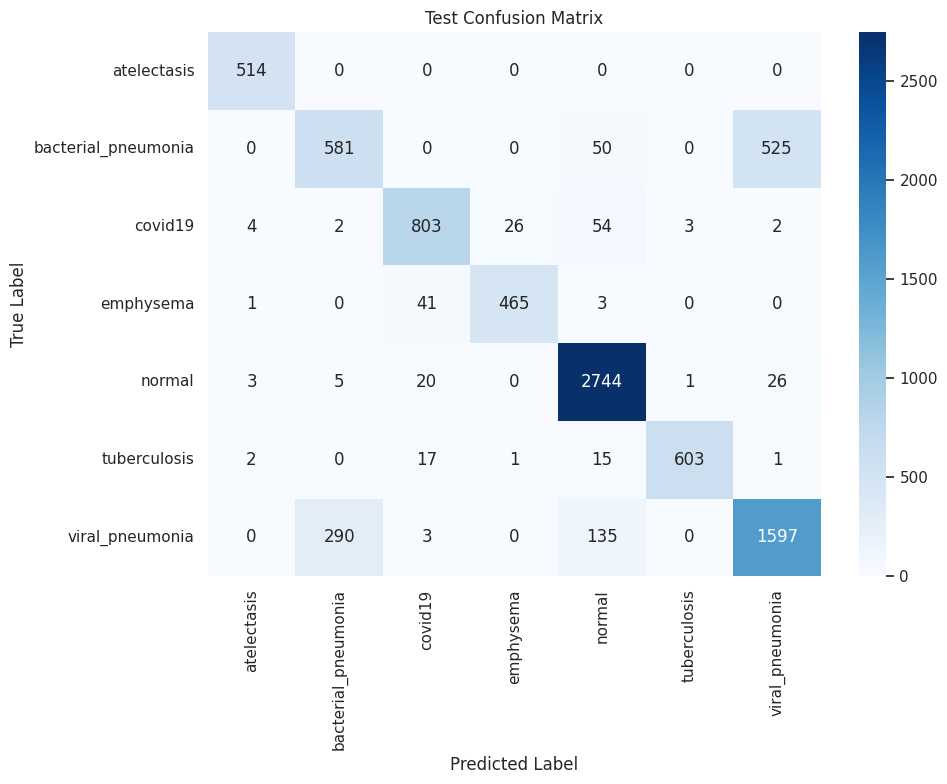

In [12]:
confusion = confusion_matrix(true_classes, predicted_classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_title("Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
fig.tight_layout()
render_figure(fig)


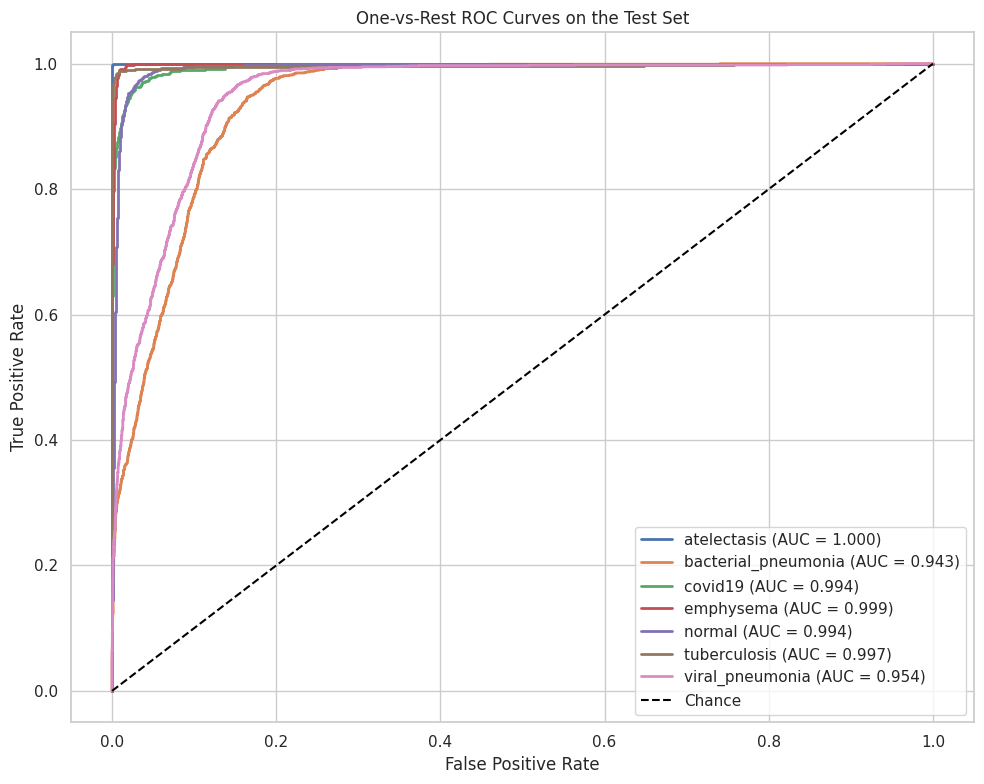

,class_name,roc_auc
0,atelectasis,1.0000
3,emphysema,0.9990
5,tuberculosis,0.9969
2,covid19,0.9942
4,normal,0.9938
6,viral_pneumonia,0.9540
1,bacterial_pneumonia,0.9427


In [13]:
roc_rows = []

fig, ax = plt.subplots(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(true_one_hot[:, class_index], predicted_probabilities[:, class_index])
    class_auc = auc(fpr, tpr)
    roc_rows.append({"class_name": class_name, "roc_auc": class_auc})
    ax.plot(fpr, tpr, linewidth=2, label=f"{class_name} (AUC = {class_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Chance")
ax.set_title("One-vs-Rest ROC Curves on the Test Set")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
fig.tight_layout()
render_figure(fig)

per_class_auc_frame = pd.DataFrame(roc_rows).sort_values("roc_auc", ascending=False)
display(per_class_auc_frame.style.format({"roc_auc": "{:.4f}"}))


## 10. Save Final Model

The best fine-tuned model is saved in both the native Keras format and the legacy HDF5 format for easier downstream integration.


In [14]:
final_keras_path = Path("/kaggle/working/final_model.keras")
final_h5_path = Path("/kaggle/working/final_model.h5")

try:
    model.save(final_keras_path)
    print(f"Saved native Keras model to: {final_keras_path.resolve()}")
except (TypeError, ValueError) as exc:
    print("Native `.keras` saving is not available in this TensorFlow build.")
    print(f"Falling back to a SavedModel export at: {final_keras_path.resolve()}")
    print(f"Original save error: {exc}")
    tf.saved_model.save(model, str(final_keras_path))

model.save(final_h5_path)
print(f"Saved HDF5 model to: {final_h5_path.resolve()}")


Saved native Keras model to: /kaggle/working/final_model.keras
Saved HDF5 model to: /kaggle/working/final_model.h5
